In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle

from numpy import sin, cos, sqrt, pi

from qc_utils import get_all_states, get_num_states, get_energy, get_selection_rules

W0 = 1 / pi # Time frequency (TAO)
U = 0.1 / W0 # Rabi Frequency (Omega)
PHI = 0.000 # Magnetic field inclination
QUBITS_NB = 3 # Number of qubits
ZETA = 100 # Zeta Value
INITIAL_ZETA = 100 # Intial Zeta Value
pp = pi/U # Pulse (pi)
hpp = pp/2 # Pulse (pi/2)
step_size = 0.005 # Step Size


def transition_stateA_stateB(E_dict, stateA, stateB):
    transition_energy = (E_dict[stateA]-E_dict[stateB])/W0
    return transition_energy

W_kj = lambda k, j: (E[k-1] - E[j-1])/W0

def diferential_equation_x_y(t, x, y, r, pos, contador, contKL, w_mag):
    global U, K, L, step_size, cuenta
    B = lambda t, k, j: W_kj(k, j) * t + w_mag * t + PHI

    if contKL == 1:
        ALPHA = 0
    elif (contKL == 2) or (contKL == 3):
        ALPHA = .5
    elif contKL == 4:
        ALPHA = 1
    else:
        ALPHA = 0

    t = t + step_size * ALPHA

    sumax = []
    sumay = []
    for i in range(len(r)):
        if pos < r[i]:
            A1 = 1
            B1 = B(t, pos, r[i])
        elif pos > r[i]:
            A1 = 0
            B1 = B(t, r[i], pos)

        ALPHA_K = ALPHA * K[contKL - 1][r[i] - 1]
        ALPHA_L = ALPHA * L[contKL - 1][r[i] - 1]
        X_rk_j = x[r[i]][contador]
        Y_rk_j = y[r[i]][contador]

        x_value = U / 2 * ((-1) ** (A1) * sin(B1) * (X_rk_j + ALPHA_K) - cos(B1) * (Y_rk_j + ALPHA_L))
        y_value = U / 2 * (cos(B1) * (X_rk_j + ALPHA_K) + (-1) ** (A1) * sin(B1) * (Y_rk_j + ALPHA_L))
        sumax.append(x_value)
        sumay.append(y_value)
        cuenta = cuenta + 1

    return sum(sumax), sum(sumay)

# Larmor Frequencies associated to each qubit.
w = [(INITIAL_ZETA + qb * ZETA) / W0 for qb in range(QUBITS_NB)]
# QUBIT-QUBIT  Interaction (ISING)
if QUBITS_NB > 1:
    j_interaction = 10
    J = []
    for i in range(QUBITS_NB - 1):
        J.append(j_interaction/((10**i)))

# All quantum states
all_states = get_all_states(n_qubits=QUBITS_NB)
all_states_dict = {num_representation+1: list(state) for num_representation, state in enumerate(all_states)}

# Count of all the possible quantum states
num_states = get_num_states(n_qubits=QUBITS_NB)

# Energy of the sistem
E = [get_energy(state, w, J, QUBITS_NB) for state in all_states]
E_dict = {num_representation + 1: get_energy(state, w, J, QUBITS_NB) for num_representation, state in enumerate(all_states)}
#DETERMINAR LAS REGLAS DE SELECCION
r = get_selection_rules(QUBITS_NB)
selection_rules = get_selection_rules(QUBITS_NB)
selection_rules_dict = {num_representation+1: list(sr) for num_representation, sr in enumerate(selection_rules)}


# Algoritmo de teleportación cuántica 3qbits

# Quantum Algorithm time delimitations
t0 = 0 #Initial time.
t1 = t0 + hpp # TIEMPOS DEFINIDOS POR PULSOS (PI O PI/2)
t2 = t1 + hpp
t3 = t2 + pp
t4 = t3 + pp
t5 = t4 + hpp
t6 = t5 + hpp
t7 = t6 + hpp
t8 = t7 + hpp
tf = t8 + hpp # TIEMPO FINAL
total_iterations = int((tf - t0)/step_size) # NUMERO DE ITERACIONES

time_pulses = [t0, t1, t2, t3, t4, t5, t6, t7, t8, tf]


v = {
    'vx': {key: np.zeros(total_iterations) for key in all_states_dict.keys()},
    'vy': {key: np.zeros(total_iterations) for key in all_states_dict.keys()}
}

c = {
    'cx': {key: np.zeros(total_iterations) for key in all_states_dict.keys()},
    'cy': {key: np.zeros(total_iterations) for key in all_states_dict.keys()}
}

D = {key: np.zeros(total_iterations) for key in all_states_dict.keys()}

N = np.zeros(total_iterations)
T = np.zeros(total_iterations)
K = np.zeros((4+1,(num_states)))
L = np.zeros((4+1,(num_states)))
cuenta=0
w_mag = 0


# TELEPORTACIÓN CUÁNTICA
#CONDICIONES INICIALES DEL SISTEMA
v["vx"][1][0] = sqrt(2/10)
v["vx"][5][0] = sqrt(8/10)

for i in range(0, total_iterations - 1):
    T[i + 1] = T[i] + step_size

    # Quantum Algorithm
    if (T[i + 1] <= t1):
        w_mag = W_kj(3, 1)
        
    elif (T[i + 1] > t1 and T[i + 1] <= t2):
        w_mag = W_kj(7, 5)
        
    elif (T[i + 1] > t2 and T[i + 1] <= t3):
        w_mag = W_kj(4, 3)

    elif (T[i + 1] > t3 and T[i + 1] <= t4):
        w_mag = W_kj(6, 5)

    elif (T[i + 1] > t4 and T[i + 1] <= t5):
        w_mag = W_kj(5, 1)

    elif (T[i + 1] > t5 and T[i + 1] <= t6):
        w_mag = W_kj(6, 2)

    elif (T[i + 1] > t6 and T[i + 1] <= t7):
        w_mag = W_kj(8, 4)

    elif (T[i + 1] > t7 and T[i + 1] <= t8):
        w_mag = W_kj(7, 3)

    elif (T[i + 1] > t8 and T[i + 1] <= tf):
        w_mag = 0

    elif (T[i + 1] > tf):
        break

    # RUNGE KUTTA:
    for m in range(1, 5):
        for j in range(2 ** QUBITS_NB):
            diff_eq_res = diferential_equation_x_y(T[i], v['vx'], v['vy'], r[j], j + 1, i, m, w_mag)
            K[m, j] = step_size * diff_eq_res[0]
            L[m, j] = step_size * diff_eq_res[1]
        cont = 0
        for x, y in zip(v['vx'].values(), v['vy'].values()):
            x[i + 1] = x[i] + (1 / 6) * (K[1, cont] + 2 * K[2, cont] + 2 * K[3, cont] + K[4, cont])
            y[i + 1] = y[i] + (1 / 6) * (L[1, cont] + 2 * L[2, cont] + 2 * L[3, cont] + L[4, cont])
            cont = cont + 1

        for position in all_states_dict.keys():
            c['cx'][position][i] = v["vx"][position][i] * cos(E_dict[position] * T[i]) - v["vy"][position][i] * sin(E_dict[position] * T[i])
            c['cy'][position][i] = v["vx"][position][i] * sin(E_dict[position] * T[i]) + v["vy"][position][i] * cos(E_dict[position] * T[i])
            D[position][i] = (c['cx'][position][i]) ** 2 + (c['cy'][position][i]) ** 2
    for position in all_states_dict.keys():
        c['cx'][position][-1] = v["vx"][position][-1] * cos(E_dict[position] * T[-1]) - v["vy"][position][-1] * sin(E_dict[position] * T[-1])
        c['cy'][position][-1] = v["vx"][position][-1] * sin(E_dict[position] * T[-1]) + v["vy"][position][-1] * cos(E_dict[position] * T[-1])
        D[position][-1] = (c['cx'][position][-1]) ** 2 + (c['cy'][position][-1]) ** 2

N=sum(D.values())


In [14]:
results = {
    'metadata': {
        'QUBITS_NB': QUBITS_NB,
        'num_states': num_states,
        'all_states_dict': all_states_dict,
        'time_pulses': time_pulses,
    },
    
    'v': v,
    'c': c,
    'D': D,
    'N': N,
    'T': T,
}

In [15]:
with open('../results/quantum_teleportation_3q.pkl', 'wb') as f:
    pickle.dump(results, f)

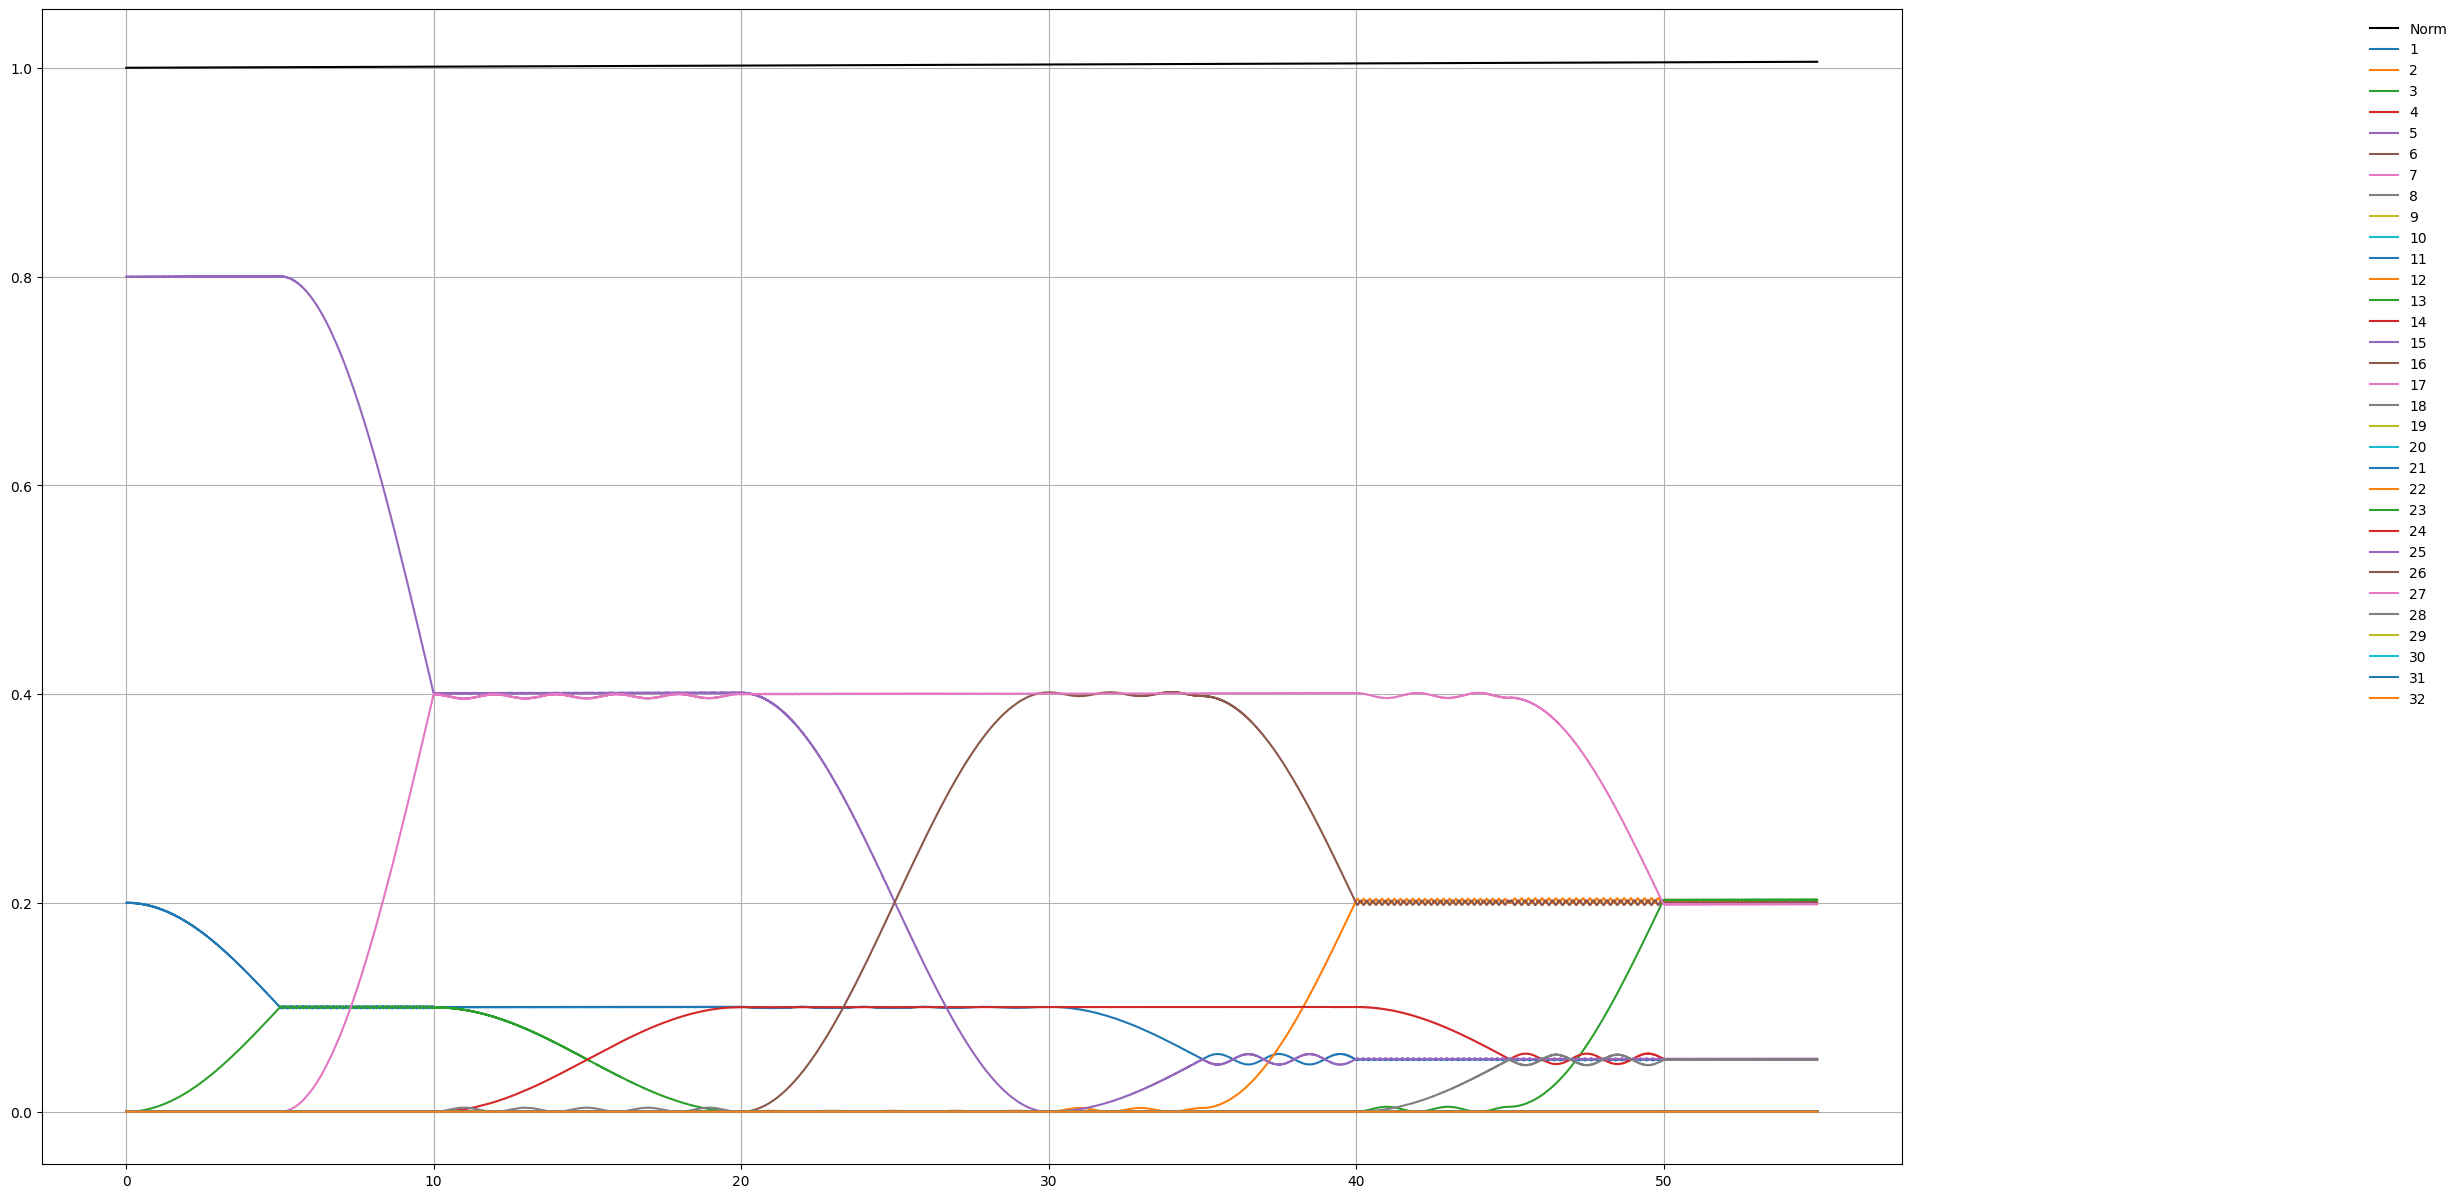